In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"


In [2]:

# Open and read the JSON file
with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
for dataset, indices in output_dict.items():
    print(f"Dataset: {dataset}")
    for index, model in indices.items():
        print(f"  Index: {index}, Best Model: {model}")

Dataset: US
  Index: bmtree, Best Model: _bits_32_depth_8_sample_10000
  Index: rlrtree, Best Model: _rlrtree_epoch_8_sample_80000
  Index: qdtree, Best Model: _episode_10_sampling_ratio_0.0001_action_space_400
Dataset: INDIA
  Index: bmtree, Best Model: _bits_32_depth_10_sample_10000
  Index: rlrtree, Best Model: _rlrtree_epoch_8_sample_40000
  Index: qdtree, Best Model: _episode_10_sampling_ratio_0.0016_action_space_400
Dataset: AUS
  Index: bmtree, Best Model: _bits_32_depth_10_sample_10000
  Index: rlrtree, Best Model: _rlrtree_epoch_8_sample_10000
  Index: qdtree, Best Model: _episode_10_sampling_ratio_0.0008_action_space_200
Dataset: UNI
  Index: bmtree, Best Model: _bits_32_depth_10_sample_10000
  Index: rlrtree, Best Model: _rlrtree_epoch_8_sample_40000
  Index: qdtree, Best Model: _episode_10_sampling_ratio_0.0004_action_space_800
Dataset: NORM
  Index: bmtree, Best Model: _bits_32_depth_10_sample_10000
  Index: rlrtree, Best Model: _rlrtree_epoch_6_sample_10000
  Index: qdtre

### Parameters

In [3]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
                   'kdtree':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_10_sample_10000',
                   'rtree':'_quadratic',
                   'zorder':'_bits_32'}


data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']

display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'PLATON',
                     
                     'Kd-tree', 'GKd-tree', 'KDB-tree', 'Waffle', 'Qd-tree', 'LISA', 
                     
                     'ZR-tree', 'ZRR-tree', 'BM-tree', 'RSMI'
                    
                    ]


### Read Only

#### Build

rtree [6.497601]
r_star_tree [55.307861]
_rlrtree_epoch_8_sample_80000
rlrtree [7.295509]
kdtree [0.0]
kdtree_greedy [0.0]
_episode_10_sampling_ratio_0.0001_action_space_400
qdtree [0.0]
zorder [0.0]
rankspace_zorder [0.0]
_bits_32_depth_8_sample_10000
bmtree [0.0]
[[125, 116]]
[[5, 30]]
[[209, 3]]
[[5], [5], [5], [21], [41], [21], [4], [4], [4]]


IndexError: list index out of range

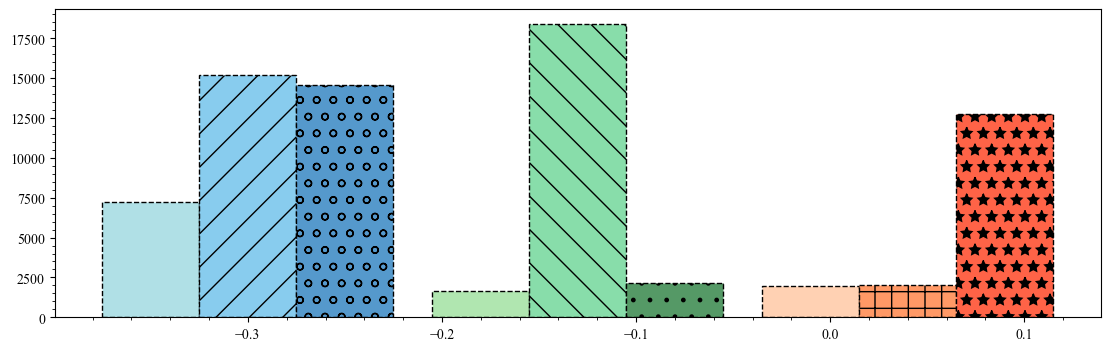

In [4]:
result = []
utilization_result = []
splits_result = []
adjustments_result = []
index_size = []
node_number = []
tree_height = []
build = []

data_names = ["us_100000000"]
display_data_names = ["US"]

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_utilization_results = []
    dataset_splits_results = []
    dataset_adjustments_results = []
    dataset_index_size = []
    dataset_node_number = []
    dataset_tree_height = []
    dataset_build = []
    
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            print(suffix)

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline), build_result_name)

        tree_property = parse_rtree_properties(res)
        
        # dataset_results.append({
        #     'ElapsedTime': tree_property.ElapsedTime,
        #     'ElapsedBuildTime': tree_property.ElapsedBuildTime,
        #     'ElapsedLearnTime': tree_property.ElapsedLearnTime
        # })

        dataset_build.append([int(tree_property.ElapsedLearnTime / 1e9 / 60) , int(tree_property.ElapsedBuildTime / 1e9 / 60)])
        # print(tree_property.ElapsedTime, tree_property.ElapsedLearnTime)
        dataset_results.append(float(tree_property.ElapsedTime / 1e9))
        dataset_utilization_results.append(tree_property.Utilization)
        dataset_splits_results.append(tree_property.Splits)
        dataset_adjustments_results.append(tree_property.Adjustments / 1e6)
        dataset_index_size.append((tree_property.TreeDatSize + tree_property.TreeIdxSize) / (1024 * 1024))
        dataset_node_number.append(tree_property.NumberOfNodes)
        dataset_tree_height.append(tree_property.TreeHeight)
        # print(baseline, data_name, tree_property.Utilization)

    result.append(dataset_results) 
    utilization_result.append(dataset_utilization_results) 
    splits_result.append(dataset_splits_results) 
    adjustments_result.append(dataset_adjustments_results) 
    print(baseline, dataset_adjustments_results)
    index_size.append(dataset_index_size)
    node_number.append(dataset_node_number)
    tree_height.append(dataset_tree_height)
    build.append(dataset_build)

# print(utilization_result)
# print(splits_result)
# print(adjustments_result)
# print(index_size)

print(build[2])
print(build[5])
print(build[8])
print(tree_height)

plot_hist(display_data_names, display_baselines, result, y_label="Build Time (s)", is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/build.pdf", "../figs/exp_sigmod/build.png"],bottom=1e2, top=5e4)

# plot_hist_stack(display_data_names, display_baselines, build, y_label="Build Time (s)",  is_log=True, output_file_paths=
#           [folder + "/figs/build.pdf", "../figs/exp/build.png"], legend_labels=["Build", "Train"])

plot_hist(display_data_names, display_baselines, index_size, y_label="Index Size (MB)", is_log=False,  output_file_paths=
          [folder + "/exp_sigmod/index_size.pdf", "../figs/exp_sigmod/index_size.png"],bottom=5000, top=15000)

plot_hist(display_data_names, display_baselines, node_number, y_label="Number of Nodes", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/node_number.pdf", "../figs/exp_sigmod/node_number.png"],bottom=1e4, top=1e7)

plot_hist(display_data_names, display_baselines, tree_height, y_label="Index Height", is_log=False, output_file_paths=
          [folder + "/exp_sigmod/tree_height.pdf", "../figs/exp_sigmod/tree_height.png"],bottom=0, top=45)


#### Point Query

_rlrtree_epoch_8_sample_80000
_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_8_sample_10000
_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_6_sample_10000
_rlrtree_epoch_6_sample_10000
_episode_10_sampling_ratio_0.0001_action_space_400
_episode_10_sampling_ratio_0.0016_action_space_400
_episode_10_sampling_ratio_0.0008_action_space_200
_episode_10_sampling_ratio_0.0004_action_space_800
_episode_10_sampling_ratio_0.0008_action_space_400
_episode_10_sampling_ratio_0.0016_action_space_200
_bits_32_depth_8_sample_10000
_bits_32_depth_10_sample_10000
_bits_32_depth_10_sample_10000
_bits_32_depth_10_sample_10000
_bits_32_depth_10_sample_10000
_bits_32_depth_10_sample_10000
[252.981183835, 204.4097162, 316.078666665, 2416.1810647800003, 243.289401805, 5264.588451795]
[68.39498151500001, 66.468538965, 114.199640105, 47.886892875, 74.539880585, 73.04059709500001]
[257.39721486999997, 177.231031005, 267.91145366499995, 99.11435936000001, 176.27390530000002, 227.19959032]
[750.58698992, 924.16952119, 

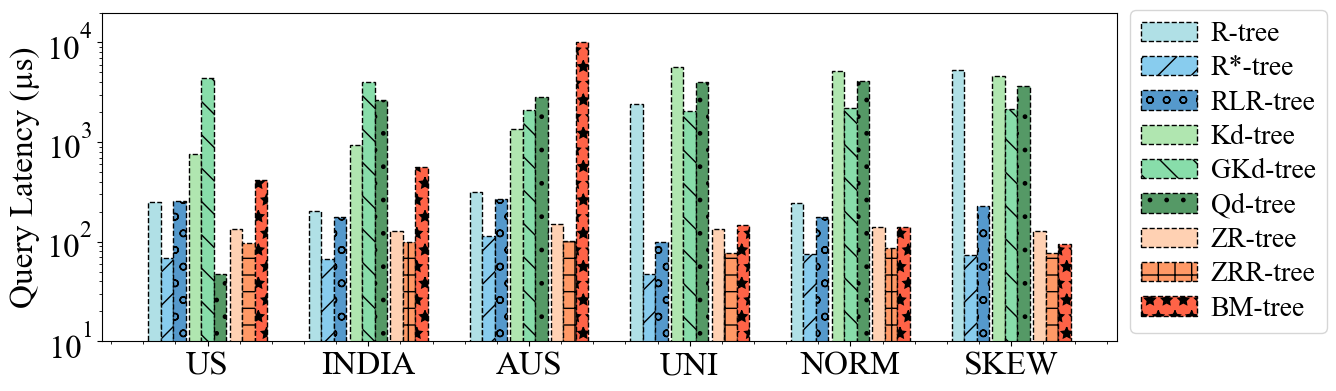

['US', 'INDIA', 'AUS', 'UNI', 'NORM', 'SKEW']


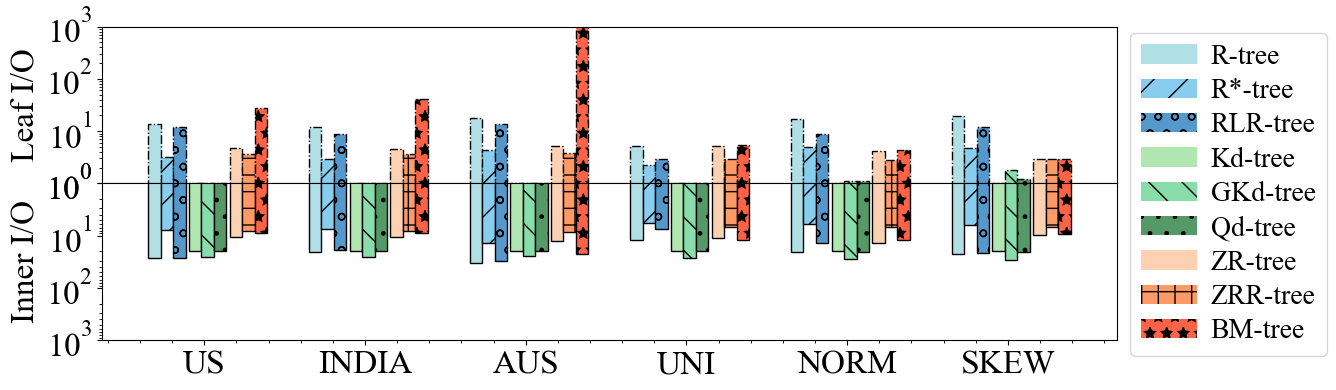

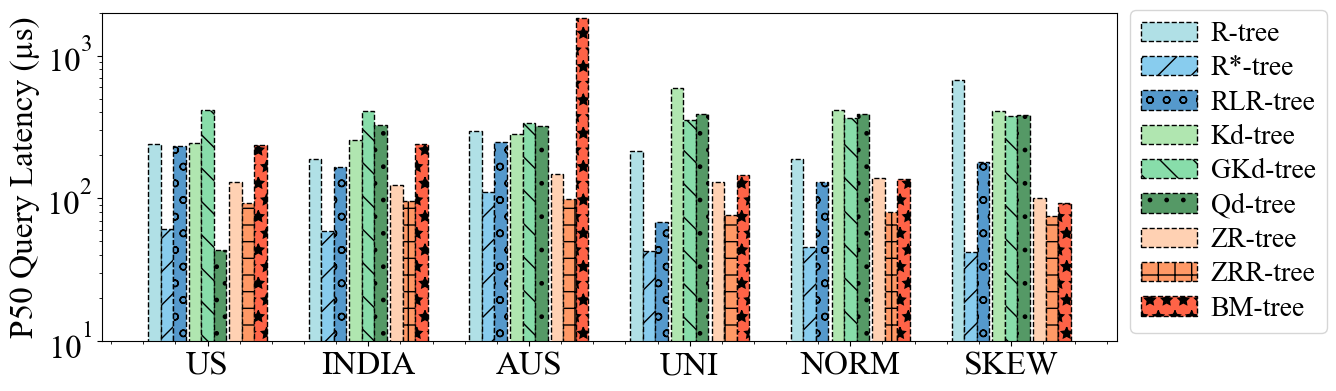

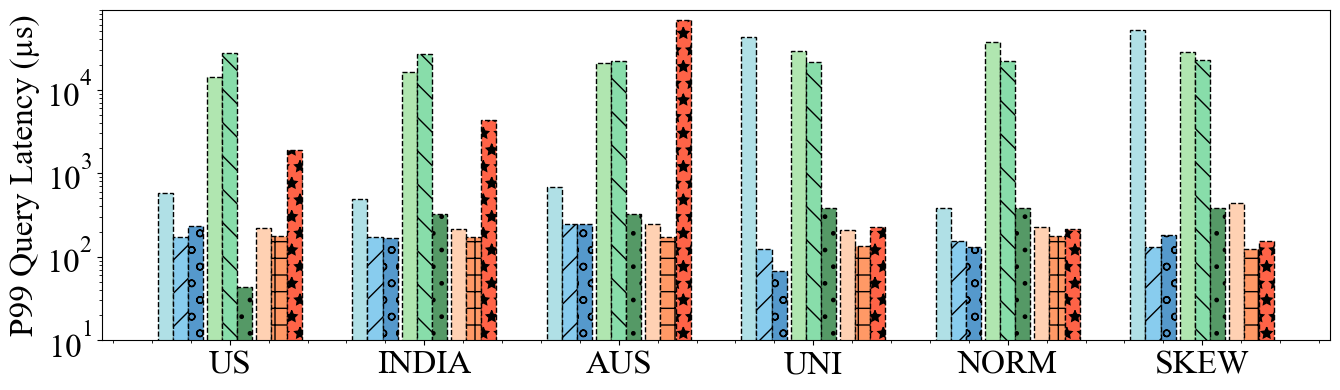

In [5]:
# 1 
# default_range_name = "_{data_name}_range_1000_2_normal_1_0.001x0.001"
real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

result = []
query_result_num = []
IO = []
P99 = []
P50 = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            print(suffix)

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline), point_result_name)
        
        tree_property = parse_rtree_properties(res)

        # self.QueryNum = kwargs.get('Query num', None)
        # self.QueryMean = kwargs.get('Query mean', None)
        # self.QueryVariance = kwargs.get('Query variance', None)
        # self.QueryStdDev = kwargs.get('Query stdDev', None)
        # self.QueryP50 = kwargs.get('Query p50', None)
        # self.QueryP99 = kwargs.get('Query p99', None)
 
        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo) / 200000)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])

    
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num)
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

for item in result:
    print(item)
# print(IO)

# print(query_result_num)
# plot_hist(display_data_names, display_baselines, query_result_num, y_label="Result Num", title="Point query result num", output_file_paths=
#           [folder + "/figs/point_result_num.pdf", "../figs/exp/point_result_num.png"])

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query.pdf", "../figs/exp_sigmod/point_query.png"], bottom=1e1, top=2*1e4)

# plot_hist(display_data_names, display_baselines, IO, y_label="I/O", output_file_paths=
#           [folder + "/figs/point_IO.pdf", "../figs/exp/point_IO.png"])

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O",  is_log=False, output_file_paths=
#           [folder + "/figs/point_IO.pdf", "../figs/exp/point_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
#                 bottom=50, top=70)

print(display_data_names)
plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_IO.pdf", "../figs/exp_sigmod/point_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=1e3, bottom2=1, top2=1e3)

# title="P50 Latency for Point Query"
plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/point_query_P50.pdf", "../figs/exp_sigmod/point_query_P50.png"], bottom=1e1, top=2*1e3)

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Query Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query_P99.pdf", "../figs/exp_sigmod/point_query_P99.png"], bottom=1e1, top=9*1e4)

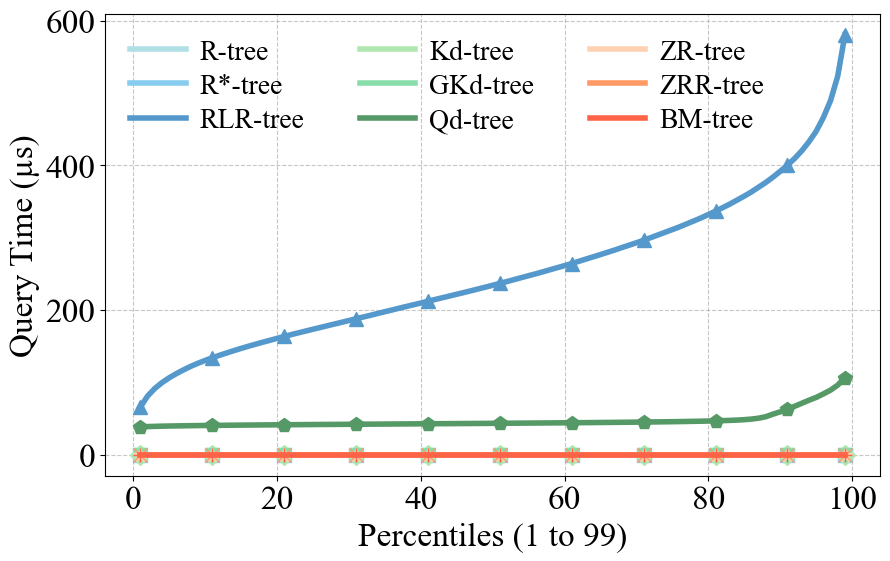

In [20]:
output_file_paths=[folder + "/exp_sigmod/point_query_percentiles.pdf", "../figs/exp_sigmod/point_query_percentiles.png"]

plot_percentail(QueryPercentage, baselines, display_baselines, xlabel="Percentiles (1 to 99)", ylabel="Query Time (µs)", output_file_paths=output_file_paths)


#### Range Query

In [ ]:
real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"
result = []
IO = []

P99 = []
P50 = []

query_result_num = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            print(suffix)
            
        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern
        else:
            range_name=real_range_name_pattern.format(data_name=data_name)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo)/1000)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num) 
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)

# print(IO)
for item in result:
    print(item)


# plot_hist(display_data_names, display_baselines, query_result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/range_query_result_num.pdf", "../figs/exp/range_query_result_num.png"])

# plot_hist(data_names, baselines, result)
plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time.pdf", "../figs/exp_sigmod/range_query_time.png"], bottom=1e1, top=2*1e6)

# plot_hist(display_data_names, display_baselines, IO, y_label="I/O", output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"])

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], legend_location="right")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO.pdf", "../figs/exp_sigmod/range_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=10000, bottom2=1, top2=10000)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P50.pdf", "../figs/exp_sigmod/range_query_P50.png"], bottom=1e1, top=2*1e6)

plot_hist(display_data_names, display_baselines, P99, is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99.pdf", "../figs/exp_sigmod/range_query_P99.png"], bottom=6*1e1, top=3*1e7)

In [ ]:
# 1 
data_name = "us_100000000"
dis_data_name = "US"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

query_range_r1 = [0.00025, 0.0005, 0.001, 0.002, 0.004]
query_range_r2 = [0.004, 0.002, 0.001, 0.0005, 0.00025]

# display_query_ranges = ["0.01%","0.05%","0.1%","0.5%","1%"]
display_query_ranges = ["1/16", "1/4", "1", "4", "16"]

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    # if baseline in output_dict[dis_data_name].keys():
    #     suffix = output_dict[dis_data_name][baseline]
    #     print(suffix)
        
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for i in range(len(query_range_r1)):
        r1 = query_range_r1[i]
        r2 = query_range_r2[i]
        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern.format(r1=r1,r2=r2)
        else:
            range_name=real_range_name_pattern.format(data_name=data_name,r1=r1,r2=r2)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)

# print(IO)
# print(result)


# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_query_ranges, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_time_varying_aspect_ratio.png"], bottom=4*1e1, top=1*1e6)

# plot_hist_stack(display_query_ranges, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO_varying_range.pdf", "../figs/exp/range_query_IO_varying_range.png"], legend_labels=["Leaf I/O", "Inner I/O"]
#                , bottom=1, top=5*1e4)

plot_hist_stack_mirrored(display_query_ranges, display_baselines, IO, y_label="I/O",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_IO_varying_aspect_ratio.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=2*1e3, bottom2=1, top2=2*1e3)

plot_hist(display_query_ranges, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P50_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_P50_varying_aspect_ratio.png"], bottom=4*1e1, top=1*1e6)

plot_hist(display_query_ranges, display_baselines, P99, y_label="P99 Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_P99_varying_aspect_ratio.png"], bottom=1e2, top=3*1e7)

In [ ]:
# 1 
data_name = "us_100000000"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

display_query_ranges = ["0.01%","0.05%","0.1%","0.5%","1%"]

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for query_range in query_ranges:

        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern.format(r1=query_range,r2=query_range)
        else:
            range_name=real_range_name_pattern.format(data_name=data_name,r1=query_range,r2=query_range)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)

# print(IO)
# print(result)


# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_query_ranges, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_varying_range.pdf", "../figs/exp_sigmod/range_query_time_varying_range.png"], bottom=4*1e1, top=1e6)

# plot_hist_stack(display_query_ranges, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO_varying_range.pdf", "../figs/exp/range_query_IO_varying_range.png"], legend_labels=["Leaf I/O", "Inner I/O"]
#                , bottom=1, top=5*1e4)

plot_hist_stack_mirrored(display_query_ranges, display_baselines, IO, y_label="I/O",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO_varying_range.pdf", "../figs/exp_sigmod/range_query_IO_varying_range.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=10000, bottom2=1, top2=10000)

plot_hist(display_query_ranges, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P50_varying_range.pdf", "../figs/exp_sigmod/range_query_P50_varying_range.png"], bottom=4*1e1, top=6*1e5)

plot_hist(display_query_ranges, display_baselines, P99, y_label="P99 Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99_varying_range.pdf", "../figs/exp_sigmod/range_query_P99_varying_range.png"], bottom=1e2, top=2*1e7)

#### knn Query

In [ ]:
# 1 
data_name = "us_100000000"
k=25
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for data_name in data_names:

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            print(suffix)

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            knn_name = synthetic_knn_name
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            knn_name = real_knn_name.format(data_name=data_name)
        
        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # print(tree_property.QueryNum, data_name, baseline)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)

for item in result:
    print(item)

# print(IO)
# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time.pdf", "../figs/exp_sigmod/knn_query_time.png"], bottom=1e2, top=2*1e5)

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O", is_log=False, output_file_paths=
#           [folder + "/figs/knn_query_IO.pdf", "../figs/exp/knn_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], bottom=0, top=150)

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_IO.pdf", "../figs/exp_sigmod/knn_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=2*1000, bottom2=1, top2=400)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P50.pdf", "../figs/exp_sigmod/knn_query_P50.png"], bottom=1e2, top=2*1e4)

plot_hist(display_data_names, display_baselines, P99, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P99.pdf", "../figs/exp_sigmod/knn_query_P99.png"], bottom=1e2, top=2*1e6)

In [ ]:
# 1 
data_name = "us_100000000"
ks=[1, 5, 25, 125, 625]
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

display_ks = [str(k) for k in ks]

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for k in ks:

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            knn_name = synthetic_knn_name
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            knn_name = real_knn_name.format(data_name=data_name)
        
        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)


# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_ks, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time_varying_k.pdf", "../figs/exp_sigmod/knn_query_time_varying_k.png"], bottom=1e1, top=3*1e4)

# plot_line(display_ks, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/knn_query_IO_varying_k.pdf", "../figs/exp/knn_query_IO_varying_k.png"])

# plot_hist_stack(display_ks, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/knn_query_IO_varying_k.pdf", "../figs/exp/knn_query_IO_varying_k.png"], legend_labels=["Leaf I/O", "Inner I/O"]
#                , bottom=0.9)

plot_hist_stack_mirrored(display_ks, display_baselines, IO, y_label="I/O",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_IO_varying_k.pdf", "../figs/exp_sigmod/knn_query_IO_varying_k.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=4*1000, bottom2=1, top2=1000)

plot_hist(display_ks, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P50_varying_k.pdf", "../figs/exp_sigmod/knn_query_P50_varying_k.png"], bottom=1e1, top=7*1e3)

plot_hist(display_ks, display_baselines, P99, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P99_varying_k.pdf", "../figs/exp_sigmod/knn_query_P99_varying_k.png"], bottom=5*1e1, top=3*1e5)

### Read heavy

In [ ]:
# 1 
synthetic_insert_point_name = "insert_point_10000000_{data_name}_2_uniform_1"
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_2_18{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
default_range_name = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

insert_result = []
query_result = []

P99 = []
P50 = []


splits = []
adjustments = []
reads = []
writes = []


for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_query_results = []
    dataset_insert_results = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_splits = []
    dataset_adjustments = []
    dataset_reads = []
    dataset_writes = []
    for data_name in data_names_write:  
            
        if data_name.startswith("data"):
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name) 
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            insert_point_name=real_insert_point_name.format(data_name=data_name) 
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
            
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)

        dataset_query_results.append(float(tree_property.QueryMean / 1000))
        dataset_insert_results.append(float(tree_property.InsertMean / 1000))
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_reads.append(tree_property.Reads)
        dataset_writes.append(tree_property.Writes)
        dataset_splits.append(tree_property.Splits * 1.0 / 100000)
        dataset_adjustments.append(tree_property.Adjustments)
        
    query_result.append(dataset_query_results) 
    insert_result.append(dataset_insert_results) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    reads.append(dataset_reads)
    writes.append(dataset_writes)
    splits.append(dataset_splits)
    adjustments.append(dataset_adjustments)

plot_hist(display_data_names, display_baselines, query_result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_query_time.pdf", "../figs/exp_sigmod/read_heavy_query_time.png"], bottom=1, top=2*1e3)

plot_hist(display_data_names, display_baselines, insert_result, y_label="Insert Latency (µs)", is_legend=False, is_log=False, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_insert_time.pdf", "../figs/exp_sigmod/read_heavy_insert_time.png"], bottom=10, top=80)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (ns)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_query_time_P50.pdf", "../figs/exp_sigmod/read_heavy_query_time_P50.png"])

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_query_time_P99.pdf", "../figs/exp_sigmod/read_heavy_query_time_P99.png"], bottom=1e1, top=2*1e4)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_insert_time_P50.pdf", "../figs/exp_sigmod/read_heavy_insert_time_P50.png"])

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_insert_time_P99.pdf", "../figs/exp_sigmod/read_heavy_insert_time_P99.png"], bottom=1e1, top=2*1e4)

# plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
#           [folder + "/figs/read_heavy_splits.pdf", "../figs/exp/read_heavy_splits.png"], top=0.5)


### Write only

In [ ]:
# 1 
data_name = "OSM_10000"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
default_range_name = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
result = []
IO = []
result_num = []

P99 = []
P50 = []

splits = []
adjustments = []
reads = []
writes = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_splits = []
    dataset_adjustments = []
    dataset_reads = []
    dataset_writes = []
    for data_name in data_names_write:        

        if data_name.startswith("data"):
            insert_name = synthetic_insert_name
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            insert_name=real_insert_name.format(data_name=data_name) 
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name,
            insert_name=insert_name,
            default_range_name=default_range_name,
            suffix=suffix
        )

        # print(insert_result_path.format(name=baseline), insert_result_name)
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.InsertMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_P50.append(tree_property.InsertP50 / 1000)
        dataset_P99.append(tree_property.InsertP99 / 1000)
        dataset_reads.append(tree_property.Reads)
        dataset_writes.append(tree_property.Writes)
        dataset_splits.append(tree_property.Splits * 1.0 / 100000)
        dataset_adjustments.append(tree_property.Adjustments)

    result.append(dataset_results)
    result_num.append(dataset_result_num)
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    reads.append(dataset_reads)
    writes.append(dataset_writes)
    splits.append(dataset_splits)
    adjustments.append(dataset_adjustments)

plot_hist(display_data_names, display_baselines, result, is_log=False, output_file_paths=
          [folder + "/exp_sigmod/write_only.pdf", "../figs/exp_sigmod/write_only.png"], bottom=1e1, top=60)

# plot_hist(display_data_names, display_baselines, P50, y_label="P50 Insert Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/write_only_P50.pdf", "../figs/exp/write_only_P50.png"])

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only_P99.pdf", "../figs/exp_sigmod/write_only_P99.png"], bottom=1e1, top=2*1e3)

plot_hist(display_data_names, display_baselines, reads, y_label="Number of Block Reads", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only_reads.pdf", "../figs/exp_sigmod/write_only_reads.png"], bottom=1e6, top=4*1e8)

plot_hist(display_data_names, display_baselines, writes, y_label="Number of Block Writes", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only_writes.pdf", "../figs/exp_sigmod/write_only_writes.png"], bottom=1e6, top=1e8)

plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
          [folder + "/exp_sigmod/write_only_splits.pdf", "../figs/exp_sigmod/write_only_splits.png"], top=2.0)

# plot_hist(display_data_names, display_baselines, adjustments, y_label="# of adjustments", is_log=True, output_file_paths=
#           [folder + "/figs/write_only_adjustments.pdf", "../figs/exp/write_only_adjustments.png"])


### Balanced

In [ ]:
# # 1 
# data_name = "us_10000000"
# default_range_name = "_{data_name}_range_1000_2_uniform_1_0.001x0.001_2_uniform_1"
# insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_10_10{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

# insert_result = []
# query_result = []

# P99_query = []
# P50_query = []
# P99_insert = []
# P50_insert = []


# splits = []
# adjustments = []
# reads = []
# writes = []


# for baseline in baselines:
#     suffix = baseline_suffix[baseline]
#     dataset_query_results = []
#     dataset_insert_results = []
#     dataset_P50_Q = []
#     dataset_P99_Q = []
#     dataset_P50_I = []
#     dataset_P99_I = []
#     dataset_splits = []
#     dataset_adjustments = []
#     dataset_reads = []
#     dataset_writes = []
#     for data_name in data_names_write:  

#         if data_name.startswith("data"):
#             insert_point_name = synthetic_insert_point_name.format(data_name=data_name) 
#             default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
#         else:
#             insert_point_name=real_insert_point_name.format(data_name=data_name) 
#             default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
            
#         insert_point_result_name = insert_point_result_name_pattern.format(
#             data_name=data_name,
#             insert_point_name=insert_point_name,
#             default_range_name=default_range_name,
#             suffix=suffix
#         )
#         res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
#         tree_property = parse_rtree_properties(res)

#         dataset_query_results.append(float(tree_property.QueryMean / 1000))
#         dataset_insert_results.append(float(tree_property.InsertMean / 1000))
#         dataset_P50_Q.append(tree_property.QueryP50 / 1000)
#         dataset_P99_Q.append(tree_property.QueryP99 / 1000)
#         dataset_P50_I.append(tree_property.InsertP50 / 1000)
#         dataset_P99_I.append(tree_property.InsertP99 / 1000)
#         dataset_reads.append(tree_property.Reads)
#         dataset_writes.append(tree_property.Writes)
#         dataset_splits.append(tree_property.Splits * 1.0 / 100000)
#         dataset_adjustments.append(tree_property.Adjustments)
        
#     query_result.append(dataset_query_results) 
#     insert_result.append(dataset_insert_results) 
#     P50_query.append(dataset_P50_Q)
#     P99_query.append(dataset_P99_Q)
#     P50_insert.append(dataset_P50_I)
#     P99_insert.append(dataset_P99_I)
#     reads.append(dataset_reads)
#     writes.append(dataset_writes)
#     splits.append(dataset_splits)
#     adjustments.append(dataset_adjustments)

# plot_hist(display_data_names, display_baselines, query_result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_query_time.pdf", "../figs/exp/balanced_query_time.png"], bottom=1, top=2*1e3)
# plot_hist(display_data_names, display_baselines, insert_result, y_label="Insert Latency (µs)", is_legend=False, is_log=True, output_file_paths=
#           [folder + "/figs/balanced_insert_time.pdf", "../figs/exp/balanced_insert_time.png"], bottom=1e1, top=1e2)

# plot_hist(display_data_names, display_baselines, P50_query, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_query_time_P50.pdf", "../figs/exp/balanced_query_P50.png"], bottom=1, top=1e3)

# plot_hist(display_data_names, display_baselines, P99_query, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_query_time_P99.pdf", "../figs/exp/balanced_query_time_P99.png"], bottom=1e1, top=2*1e4)

# plot_hist(display_data_names, display_baselines, P50_insert, y_label="P50 Insert Latency (µs)", is_log=False, output_file_paths=
#           [folder + "/figs/balanced_insert_time_P50.pdf", "../figs/exp/balanced_insert_time_P50.png"], bottom=1e1, top=3*1e1)

# plot_hist(display_data_names, display_baselines, P99_insert, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_insert_time_P99.pdf", "../figs/exp/balanced_insert_time_P99.png"], bottom=1e1, top=2*1e3)

# plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
#           [folder + "/figs/balanced_splits.pdf", "../figs/exp/balanced_splits.png"], bottom=0, top=1.5)

### Write heavy

In [ ]:
# 1 
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_18_2{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

insert_result = []
query_result = []


P99_query = []
P50_query = []
P99_insert = []
P50_insert = []

splits = []
adjustments = []
reads = []
writes = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_query_results = []
    dataset_insert_results = []
    dataset_P50_Q = []
    dataset_P99_Q = []
    dataset_P50_I = []
    dataset_P99_I = []
    dataset_splits = []
    dataset_adjustments = []
    dataset_reads = []
    dataset_writes = []
    for data_name in data_names_write:  
            
        if data_name.startswith("data"):
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name) 
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            insert_point_name=real_insert_point_name.format(data_name=data_name) 
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
            
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )

        # print(insert_point_result_path.format(name=baseline), insert_point_result_name)
        
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)

        dataset_query_results.append(float(tree_property.QueryMean / 1000))
        dataset_insert_results.append(float(tree_property.InsertMean / 1000))
        dataset_P50_Q.append(tree_property.QueryP50 / 1000)
        dataset_P99_Q.append(tree_property.QueryP99 / 1000)
        dataset_P50_I.append(tree_property.InsertP50 / 1000)
        dataset_P99_I.append(tree_property.InsertP99 / 1000)
        dataset_reads.append(tree_property.Reads)
        dataset_writes.append(tree_property.Writes)
        dataset_splits.append(tree_property.Splits * 1.0 / 100000) # 1/100000 = 1/10000000 * 100
        dataset_adjustments.append(tree_property.Adjustments)
        
    query_result.append(dataset_query_results) 
    insert_result.append(dataset_insert_results) 
    P50_query.append(dataset_P50_Q)
    P99_query.append(dataset_P99_Q)
    P50_insert.append(dataset_P50_I)
    P99_insert.append(dataset_P99_I)
    reads.append(dataset_reads)
    writes.append(dataset_writes)
    splits.append(dataset_splits)
    adjustments.append(dataset_adjustments)

plot_hist(display_data_names, display_baselines, query_result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_query_time.pdf", "../figs/exp_sigmod/write_heavy_query_time.png"], bottom=1, top=2*1e3)
plot_hist(display_data_names, display_baselines, insert_result, is_legend=False, is_log=False, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_insert_time.pdf", "../figs/exp_sigmod/write_heavy_insert_time.png"], bottom=1e1, top=60)

plot_hist(display_data_names, display_baselines, P50_query, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_query_time_P50.pdf", "../figs/exp_sigmod/write_heavy_query_time_P50.png"], bottom=1, top=1e3)

plot_hist(display_data_names, display_baselines, P99_query, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_query_time_P99.pdf", "../figs/exp_sigmod/write_heavy_query_time_P99.png"], bottom=1e1, top=2*1e4)

plot_hist(display_data_names, display_baselines, P50_insert, y_label="P50 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_insert_time_P50.pdf", "../figs/exp_sigmod/write_heavy_insert_time_P50.png"], bottom=1, top=1e2)

plot_hist(display_data_names, display_baselines, P99_insert, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_insert_time_P99.pdf", "../figs/exp_sigmod/write_heavy_insert_time_P99.png"], bottom=1e1, top=2*1e3)

plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
          [folder + "/exp_sigmod/write_heavy_splits.pdf", "../figs/exp_sigmod/write_heavy_splits.png"], bottom=0, top=2.0)

In [ ]:
data_names = ["us_100000000"]
data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000"]
display_data_names = ["US"]
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

data_name = "us_100000000"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

baselines = ['rlrtree', 'qdtree',  'bmtree']
display_baselines = ['RLR-tree', 'Qd-tree', 'BM-tree']


In [ ]:
disk_types = ["HDD", "SSD"]

query_types = ["Index Building", "Point Query", "Range Query", "$k$NN Query"]

build_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/build/"
point_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/point/"
range_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/knn/"

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
                   'kdtree':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_10_sample_10000',
                   'rtree':'_quadratic',
                   'zorder':'_bits_32'}

data_names = ["us_100000000"]
display_data_names = ["US"]
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

In [ ]:
data_name = "us_100000000"
k=25
point_query = []
range_query = []
knn_query = []
build_time = []

for baseline in baselines:
    point_query_sampled = []
    range_query_sampled = []
    knn_query_sampled = []
    build_time_sampled = []
    for disk_type in disk_types:    

        suffix = baseline_suffix[baseline]

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)

        # default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        range_name=real_range_name_pattern.format(data_name=data_name)
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        # print(build_result_name)
        res = os.path.join(build_result_path.format(name=baseline,disk_type=disk_type), build_result_name)
        tree_property = parse_rtree_properties(res)
        # build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9)
        build_time_sampled.append(tree_property.ElapsedTime / 1e9)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )
        
        res = os.path.join(point_result_path.format(name=baseline,disk_type=disk_type), point_result_name)
        tree_property = parse_rtree_properties(res)
        point_query_sampled.append(tree_property.QueryMean / 1e3)


        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        # print(range_result_name)

        res = os.path.join(range_result_path.format(name=baseline,disk_type=disk_type), range_result_name)
        tree_property = parse_rtree_properties(res)
        range_query_sampled.append(tree_property.QueryMean / 1e3)

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline,disk_type=disk_type), knn_result_name)
        tree_property = parse_rtree_properties(res)
        knn_query_sampled.append(tree_property.QueryMean / 1e3)

        # print(build_result_path.format(name=baseline,disk_type=disk_type), build_result_name)
        # print(point_result_path.format(name=baseline,disk_type=disk_type),point_result_name)
        # print(range_result_path.format(name=baseline,disk_type=disk_type), range_result_name)
        # print(knn_result_path.format(name=baseline,disk_type=disk_type), knn_result_name)
    #     break
    # break

    point_query.append(point_query_sampled)
    range_query.append(range_query_sampled)
    knn_query.append(knn_query_sampled)
    build_time.append(build_time_sampled)
    


print(point_query)
# print(range_query)
# print(knn_query)
# print(build_time)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
colors = ['#A9A9F5', '#FFD700', '#88CCEE', '#FFCC99', '#FFA07A', '#FF6F61', '#B0E0E6', '#2CA02C', '#AA4499']

all_data = [build_time, range_query, point_query, knn_query]
query_types = ['Index Building', 'Range Query', 'Point Query', 'kNN Query']
bottoms = [1e3, 1*1e3, 1e1, 1e2]
tops = [2*1e5, 2*1e6, 2*1e4, 2*1e4]

# display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

group_width = 0.8  
individual_bar_width = group_width / 2  
offset = individual_bar_width / 2  

fig, axes = plt.subplots(2, 2, figsize=(9, 4), sharey=False)

for i, (ax, query_type, data) in enumerate(zip(axes.flat, query_types, all_data)):
    x = np.arange(len(display_baselines)) 
    
    hdd_values = [row[0] for row in data] 
    ssd_values = [row[1] for row in data] 
    
    ax.bar(x - offset, hdd_values, individual_bar_width, label='HDD', color=colors[0], alpha=1.0) 
    ax.bar(x + offset, ssd_values, individual_bar_width, label='SSD', color=colors[1], alpha=1.0) 


    ax.set_title(f'{query_type}', fontsize=16)
    if i > 1:
        ax.set_xticks(x)  
        ax.set_xticklabels(display_baselines, rotation=45, ha='right') 
    else:
        ax.set_xticks([])  
        

    if i == 0:
        ax.set_ylabel('Build Time (s)') 
    else:
        ax.set_ylabel('Query Time (µ)') 

    ax.set_ylim(bottom=bottoms[i])
    ax.set_ylim(top=tops[i])
    
    ax.set_yscale('log')
    ax.grid(True, axis='y', linestyle='--', alpha=1.0)

axes[0, 0].legend(loc='upper left', fontsize=14, ncol=2)  

output_file_paths = [folder + "/exp_sigmod/hdd_vs_ssd.pdf", "../figs/exp_sigmod/hdd_vs_ssd.png"]

plt.tight_layout()

if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')


plt.show()

In [ ]:

data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM", "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_10_10{suffix}.txt"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"

spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize

    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_write_only[display_baseline] = tree_property.InsertMean
        
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean    

    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np


label_size = 24
legend_size = 20
categories = ['Size', 'Build Time', 'Point', 'Range', 'Knn', 'Write-Only']
letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Define the number of subplots (2 rows, 3 columns for 6 subplots)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), subplot_kw=dict(polar=True))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+']
linestyles = [None, None, '-', None, None, '--', None, None, '-.']

for j, ax in enumerate(axs):

    # baseline = []
    for i, display_baseline in enumerate(display_baselines):

        baseline = [
        spider_index_size[j][display_baseline],
        spider_build_time[j][display_baseline],
        spider_point_query[j][display_baseline],
        spider_range_query[j][display_baseline],
        spider_knn_query[j][display_baseline],
        # spider_balanced[j][display_baseline],
        spider_write_only[j][display_baseline]]
        # baseline = [random.randint(1, 9) for _ in range(len(categories))]
        baseline += baseline[:1]
        ax.plot(angles, baseline, color=colors[i], linewidth=3, marker=markers[i], markersize=10, label=display_baseline)


    # Fill in the labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=label_size)
    ax.set_title(letters[j] + " " + display_data_names[j], fontsize=label_size)

#     if j == 1:
#         # Add a legend for each subplot
#         ax.legend(loc='upper center', fontsize=legend_size, bbox_to_anchor=(0.5, 1.15), ncol=9)  # Adjust the position and columns

fig.legend(display_baselines, loc='upper center', fontsize=label_size, ncol=5, bbox_to_anchor=(0.5, 1.0))

        # borderaxespad=0.5,  # Border padding
        # handletextpad=0.5,  # Padding between legend marker and text
        # labelspacing=0.3    # Vertical space between legend entries

# Adjust layout to prevent overlap
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the legend

# plt.tight_layout(pad=1.0, w_pad=2.0, h_pad=0.0)

# pad: Padding between the figure edge and the edges of subplots.
# w_pad: Padding (width) between subplots.
# h_pad: Padding (height) between subplots.

# left, right, top, bottom: Control the margins around the entire figure.
# wspace: Controls the width space between the subplots.
# hspace: Controls the height space between the subplots.

plt.subplots_adjust(wspace=0.4, hspace=0.02)


# Adjust layout to prevent overlap
# plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/spider.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/spider.png", format='png', bbox_inches='tight')

# Show the entire figure with all subplots
plt.show()


In [ ]:
data_names = ["us_100000000", "australia_100000000"]
data_names_write = ["us_10000000", "australia_10000000"]
display_data_names = ["US", "AUS"]


spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize

    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_write_only[display_baseline] = tree_property.InsertMean
        
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean    

    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)

import matplotlib.pyplot as plt
import numpy as np
import random

label_size = 24
legend_size = 20
categories = ['Size', 'Build Time', 'Point', 'Range', '$K$NN', 'Write-Only']
letters = ["(a)", "(b)"]
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Define the number of subplots (2 rows, 3 columns for 6 subplots)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 12), subplot_kw=dict(polar=True))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+']
linestyles = [None, None, '-', None, None, '--', None, None, '-.']

for j, ax in enumerate(axs):

    # baseline = []
    for i, display_baseline in enumerate(display_baselines):

        baseline = [
        spider_index_size[j][display_baseline],
        spider_build_time[j][display_baseline],
        spider_point_query[j][display_baseline],
        spider_range_query[j][display_baseline],
        spider_knn_query[j][display_baseline],
        # spider_balanced[j][display_baseline],
        spider_write_only[j][display_baseline]]
        # baseline = [random.randint(1, 9) for _ in range(len(categories))]
        baseline += baseline[:1]
        ax.plot(angles, baseline, color=colors[i], linewidth=3, marker=markers[i], markersize=10, label=display_baseline)


    # Fill in the labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=label_size)
    ax.set_title(letters[j] + " " + display_data_names[j], fontsize=label_size)

#     if j == 1:
#         # Add a legend for each subplot
#         ax.legend(loc='upper center', fontsize=legend_size, bbox_to_anchor=(0.5, 1.15), ncol=9)  # Adjust the position and columns

fig.legend(display_baselines, loc='upper center', fontsize=label_size, ncol=5, bbox_to_anchor=(0.5, 0.88))


plt.subplots_adjust(wspace=0.4, hspace=0.02)


# Adjust layout to prevent overlap
# plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/spider.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/spider.png", format='png', bbox_inches='tight')

# Show the entire figure with all subplots
plt.show()
